In [1]:
import warnings
from typing import List, Literal, Optional, Tuple

import moscot as mt
import moscot.plotting as mtp
import ot
import tqdm
from moscot.problems.time import LineageProblem, TemporalProblem

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import euclidean_distances

import matplotlib.pyplot as plt
import pycea as py

import scanpy as sc
from anndata import AnnData
import treedata as td

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

Early run, only **first replicate** is used. Since there are also multiple clones in the replicate, I will take the clone with the biggest lineage tree and as a result should probably subset the data before we concat. 
TODO: Figure out why there are multiple clones. Why the nodes in the tree and the clone cell count do not match up 
TODO: Create cost matrix for each time point, and the cost matrix 
TODO: Use Gene Expression for cost matrix across time points 

#### Data loading

In [5]:
from pathlib import Path
basePath = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_data = basePath + "output_data/"
output_plot = basePath + "output_plot/"

In [13]:
Lineage_data = Path("/project/imoskowitz/kdreyer/public_datasets/005_Colgan2026/")
tdatas = {}
for file_path in Lineage_data.glob("*R1.h5td"): # Taking only the first replicate

    #tdatas[file_path.stem] = td.read_h5td(file_path)

    # For testing, extract only timepoint lower than E9.0
    # Extract stage from filename (e.g., "E8.5-R1" from "E8.5-R1-C1.h5td")
    stem = file_path.stem
    stage = stem.split("-")[0]  # Extract "E8.5", "E9.0", etc.
    
    # Parse the stage to compare versions (e.g., E8.5, E9.0)
    stage_num = float(stage[1:])  # Remove 'E' and convert to float
    
    # Exclude E8.5 and above
    if stage_num < 8.5:
        tdatas[stem] = td.read_h5td(file_path)

In [15]:
for tdata in tdatas.values():
    print(tdata)

TreeData object with n_obs × n_vars = 1342 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree'
    var: 'gene_ids', 'mito', 'chromosome'
    obsm: 'X_scvi', 'X_umap', 'characters'
    obst: 'E7.5-R1-C1', 'E7.5-R1-C2'
TreeData object with n_obs × n_vars = 4498 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree'
    var: 'gene_ids', 'mito', 'chromosome'
    obsm: 'X_scvi', 'X_umap', 'characters'
    obst: 'E8.0-R1-C1', 'E8.0-R1-C2', 'E8.0-R1-C3'


#### Concat Different Days into one adata (All replicate, all clones, all days)


In [16]:
merged_tdata = td.concat(tdatas, merge='unique')

In [17]:
import gc
del tdatas # Free up memory
gc.collect()

65452

In [21]:
merged_tdata

TreeData object with n_obs × n_vars = 5840 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree'
    var: 'gene_ids', 'mito', 'chromosome'
    obsm: 'X_scvi', 'X_umap', 'characters'
    obst: 'E7.5-R1-C1', 'E8.0-R1-C3', 'E8.0-R1-C1', 'E7.5-R1-C2', 'E8.0-R1-C2'

In [19]:
for obs in merged_tdata.obs:
    print("------------"+obs+"--------")
    print("---------------------------")
    print(set(merged_tdata.obs[obs])) 
    print("---------------------------")

# Note, "stage" obs contain time point

------------cell_subtype--------
---------------------------
{'Endothelial progenitor', 'Extraembryonic ectoderm', 'Epiblast', 'Surface ectoderm (anterior)', 'First heart field', 'Nascent mesoderm', 'Nascent somite', 'Presomitic mesoderm', 'Definitive endoderm', 'Gut', 'Spinal cord', 'Anterior mesoderm', 'Intermediate mesoderm', 'Extraembryonic mesoderm', 'Hematoendothelial progenitor', 'Axial progenitor', 'Notochord', 'Juxtacardiac field', 'Visceral endoderm', 'Second heart field (anterior)', 'Primitive streak', 'Second heart field (posterior)', 'Hindbrain', 'Primordial germ cell', 'Allantois', 'Lateral plate mesoderm', 'Allantoic endothelial progenitor', 'Surface ectoderm (posterior)', 'Rostral ectoderm', 'Forebrain'}
---------------------------
------------capture--------
---------------------------
{'E8.0-R1-T1', 'E7.5-R1-T1'}
---------------------------
------------embryo--------
---------------------------
{'E7.5-R1', 'E8.0-R1'}
---------------------------
------------stage------

#### Normalize and PCA

In [ ]:
# Implementing fastrna for more efficient PCA analysis
#from fastrna.core import *

In [23]:
# Saving raw gene expression as a layer 
merged_tdata.layers['raw'] = merged_tdata.X.copy()


#### Pearson norm

In [13]:
# Pearson normalize, compute pca, plot pca
sc.experimental.pp.recipe_pearson_residuals(merged_tdata, n_comps=50, n_top_genes=2000, chunksize=1000, clip=np.sqrt(merged_tdata.n_obs))

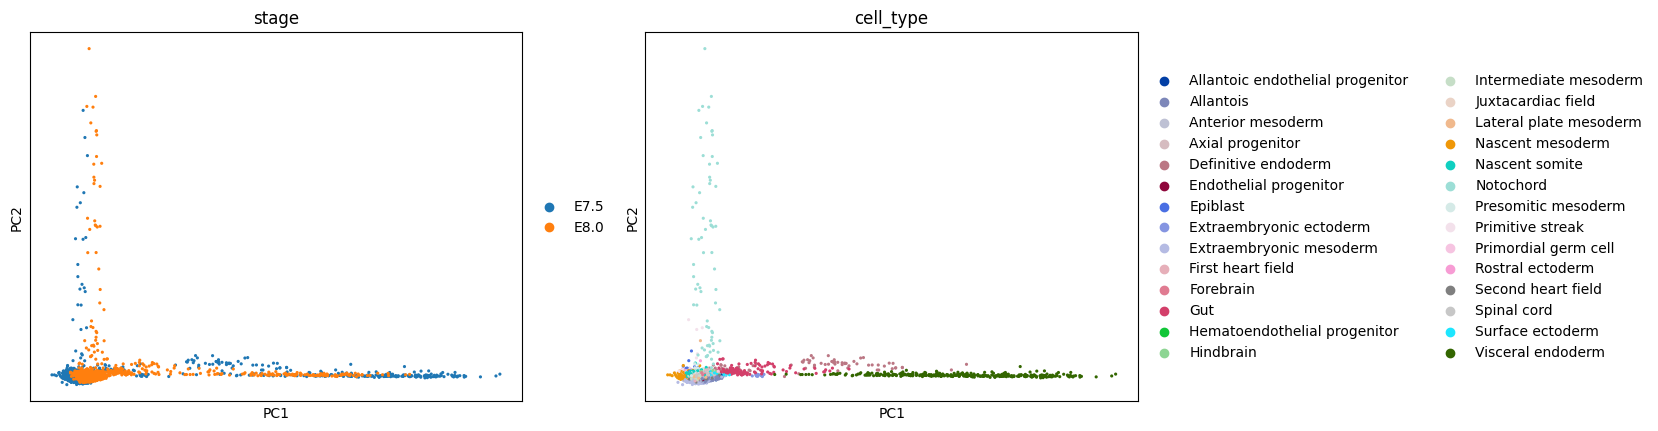

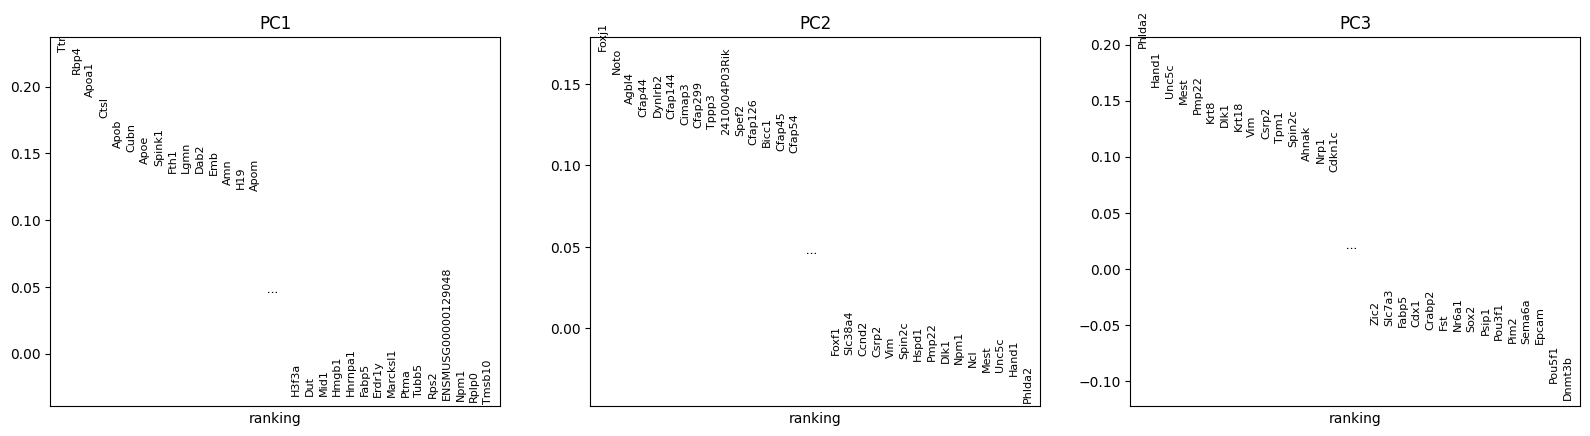

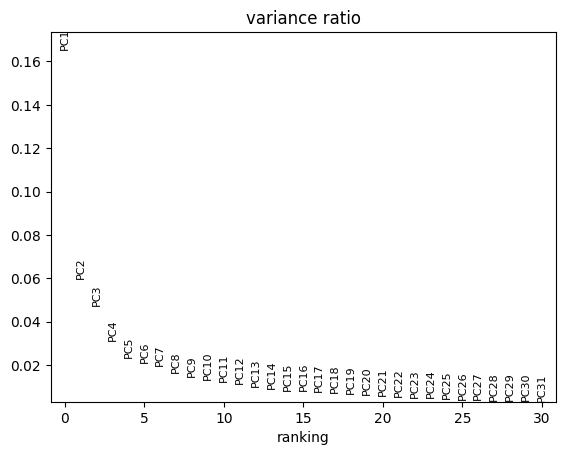

In [14]:
sc.pl.pca_overview(merged_tdata, color = ["stage", "cell_type"],)

#### Log2p Norm - Sanity Check (Basically Don't run )

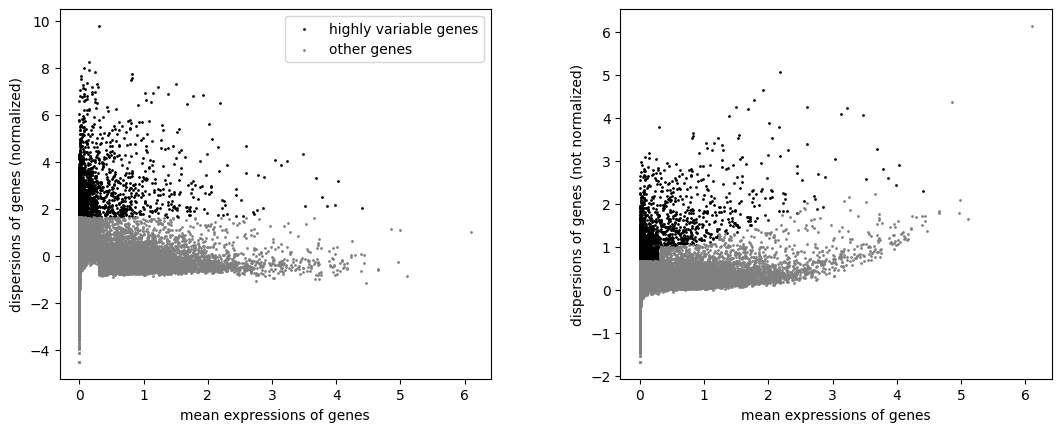

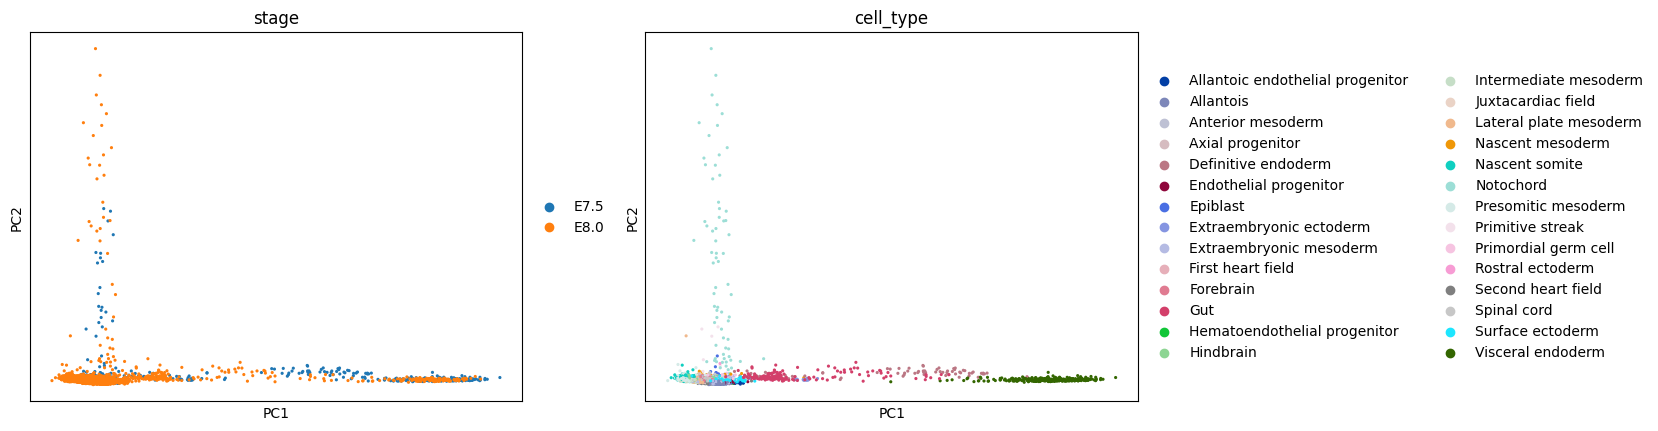

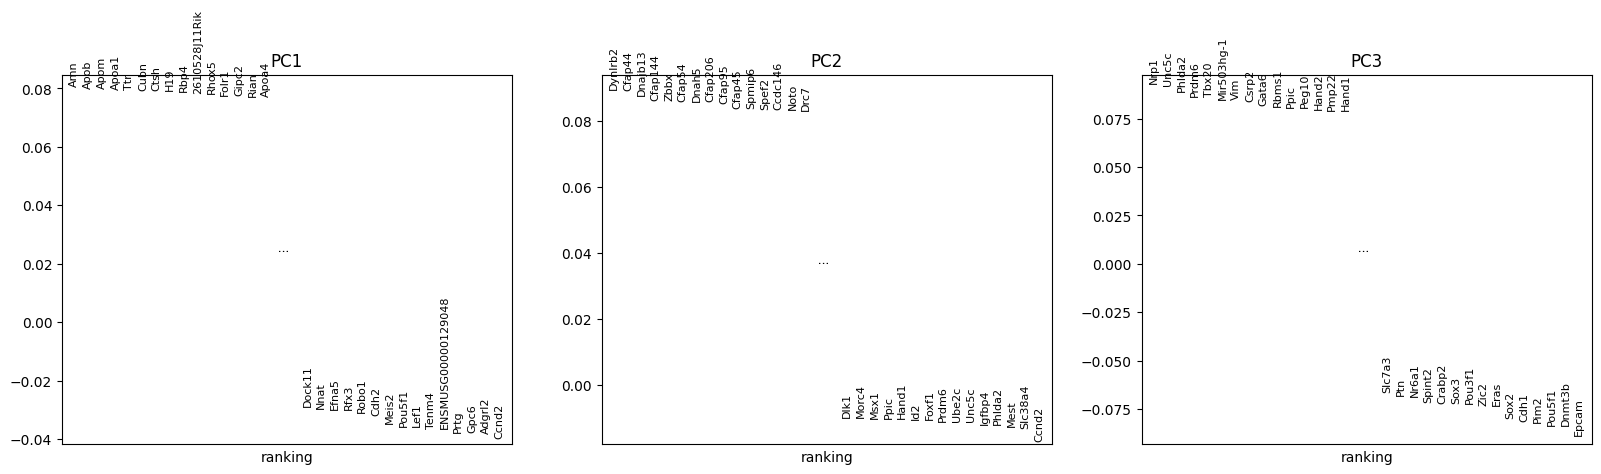

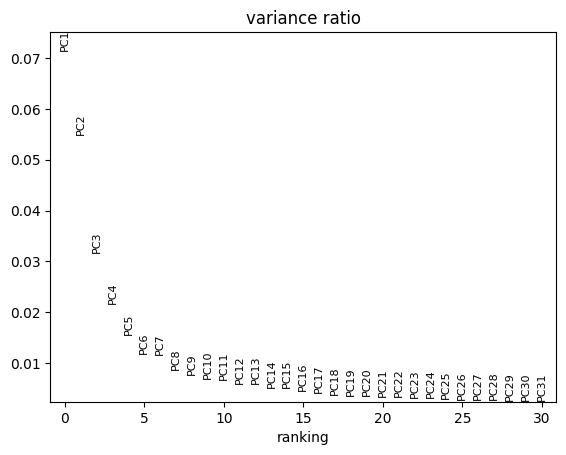

In [12]:
sc.pp.normalize_total(merged_tdata)
sc.pp.log1p(merged_tdata)
sc.pp.highly_variable_genes(merged_tdata, n_top_genes=2000)
sc.pl.highly_variable_genes(merged_tdata, show=True)

sc.pp.scale(merged_tdata) # Centered around 0 

sc.pp.pca(merged_tdata, random_state=0, use_highly_variable=True)

sc.pl.pca_overview(merged_tdata, color=["stage", "cell_type"])

#### Matrix Filtering and Datatype conversion

In [16]:
# Check what kind of characters are in this obsm
np.unique(merged_tdata.obsm['characters'])

array(['!', '*', '-', '1', '2', '3', '4', '5', '6', '7', '8'],
      dtype=object)

In [17]:
chars = merged_tdata.obsm["characters"]
print(chars.shape)         # should be (n_cells, n_target_sites)
#print(pd.DataFrame(chars).head(1))   # inspect values; expect integers or floats, not all zeros
print(pd.DataFrame(chars))  # each column should have >1 unique value if informative

(5840, 99)
                              intID1039-EMX1 intID1039-HEK3 intID1039-RNF2  \
E7.5-R1-T1-GGAGTTAGTTCGAGCC-1              *              *              *   
E7.5-R1-T1-ACCGGATTCCGCAGAT-1              *              *              *   
E7.5-R1-T1-TGCTAACGTTAGACGA-1              *              *              *   
E7.5-R1-T1-AGTGTCATCCTTCAAC-1              *              *              *   
E7.5-R1-T1-CTTCAGCCAAGGGATA-1              *              *              *   
...                                      ...            ...            ...   
E8.0-R1-T1-TGGGTGAAGTCAAGCC-1              -              -              -   
E8.0-R1-T1-TGGTCCTCACTCGGAA-1              -              -              -   
E8.0-R1-T1-TGTAGCGCAATCGAGT-1              -              -              -   
E8.0-R1-T1-TGTCGATGTGCAATCT-1              -              -              -   
E8.0-R1-T1-TGTCGTTTCGTGAGGA-1              -              -              -   

                              intID1068-EMX1 intID10

In [18]:
# Cleaning up the character matrix so it contains only string
chars = np.where(chars == '*', 0, chars) # no edit
chars = np.where(chars == '-', -1, chars) # not detected
chars = np.where(chars == "!", 999, chars) # Not editable, but is detected

# Note, those classifications were given by claude. Need to confirm with the author whether those are actually the correct labeling
chars = chars.astype(int)

In [19]:
merged_tdata.obsm['X_characters'] = chars.astype(int)

In [20]:
merged_tdata.obsm['X_characters'].dtype

dtype('int64')

In [21]:
np.unique(merged_tdata.obsm['X_characters'])

array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8, 999])

#### Creating a column for numeric time


In [22]:
# need to make a time variable that is categorical with numeric based
merged_tdata.obs["time"] = pd.to_numeric(merged_tdata.obs['stage'].str[1:]).astype('category')

In [23]:
merged_tdata.obs['time'].unique()

[7.5, 8.0]
Categories (2, float64): [7.5, 8.0]

In [24]:
lp = LineageProblem(merged_tdata)

# In order to pass in cells that has no lineage barcode detection, the _scaled_hamming_dist() function was modified st instead of returning a 
# Error, a large distance was returned. Note, this is one way to solve this problem of no detection. Worth thinking and trying other solutions
lp = lp.prepare(
    time_key="time",
    joint_attr="X_pca",
    lineage_attr={"attr": "obsm", "key": "X_characters", "cost": "barcode_distance"},
    
)

INFO     Computing barcode distance                                                                                
INFO     Computing barcode distance                                                                                


In [25]:
lp.solve()

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(1342, 4498)].                                  
WARNING  Solver did not converge                                                                                   


LineageProblem[(7.5, 8.0)]

# Checkpoint

In [27]:
lp.save(output_data+"lp_two_days.pkl")